In [1]:
import numpy as np
import scipy.stats as stats
from scipy.io import loadmat
import matplotlib.pyplot as plt
from particles_cdssm.sdes import MvEllipticSDE, IntegratedSDE
import particles_cdssm.auxiliary_bridges as axb

plt.style.use('ggplot')

# The model

The Fitzhugh-Nagumo (FHN) model is given as follows:
\begin{align}
dV_t &= \frac{1}{\epsilon} (V_t - V_t^3 - U_t - s) dt \\
dU_t &=(\gamma V_t - U_t + \beta) dt + \sigma dB_t
\end{align}

We have parameter vector $\theta = (\epsilon, \gamma, \beta, \sigma)$. We define a class for this model below for the case where $s=0$, and simulate from the process:

In [2]:
class FitzHughNagumo(MvEllipticSDE):
    """
    Stochastic Fitzhugh-Nagumo model, as in Samson et al (2025)
    
    https://www.sciencedirect.com/science/article/pii/S0167947324001798?via%3Dihub

    dV_t = 1/epsilon * (V_t - V_t^3 - U_t) dt
    dU_t = gamma * V_t - U_t + beta dt + sigma_u dB_t
    """
    dimX = 2
    default_params = {'epsilon': 0.1,
                      'gamma': 1.5,
                      'beta': 0.8,
                      'sigma_u': 0.3
                    }

    def b(self, t, x):
        x_1 = 1/self.epsilon * (x[:, 0] - (x[:, 0] ** 3) - x[:, 1]) # (N, )
        x_2 = self.gamma * x[:, 0] - x[:, 1] + self.beta # (N, )
        return np.stack([x_1, x_2], axis=1)

    def sigma(self, t, x):
        N = x.shape[0]
        return np.stack([np.array([[0.0, 0.0], [0.0, self.sigma_u]])]*N, axis=0)

In [3]:
t_start = 0.; t_end = 100
delta_t = 0.002 # Same as the real data sampling rate
num = int((t_end - t_start) / delta_t)
times = np.linspace(t_start, t_end, num)

sde = FitzHughNagumo()

# np.random.seed(42)  # For reproducibility
x_0 = np.zeros((1, 2))

samples = sde.simulate(1, t_start=t_start, t_end=t_end, x_start=x_0, num=num)
samples_arr = np.array([samples[name] for name in samples.dtype.names])[:, 0, :]
V_t = samples_arr[:, 0]
U_t = samples_arr[:, 1]
Z_t  =(1/sde.epsilon) *  (V_t - V_t**3 - U_t)

We need to determine a subsampling rate such that it is necessary to use data augmentation to infer the path of the diffusion process. A visualisation of a simulation of the true process, along with subsamples from the true process are useful in this direction:

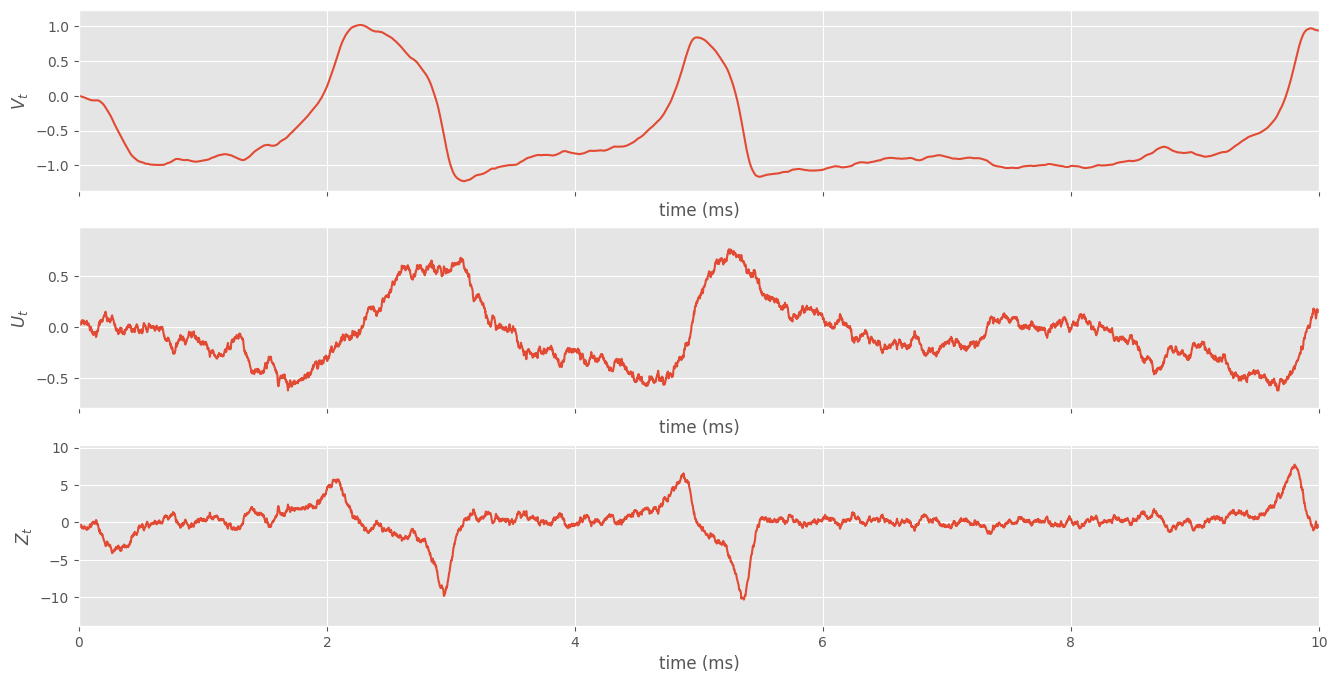

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True, squeeze=True)


axes[0].plot(times, V_t, label=r'$V_t$')
axes[1].plot(times, U_t, label=r'$U_t$')
axes[2].plot(times, Z_t, label=r'$Z_t$')

# subsample_delta_t = 0.5
# sample_rate = int(subsample_delta_t / delta_t)

# axes[0].plot(times[::sample_rate], samples_arr[:, 0][::sample_rate], 'o', markersize=5.0)
# axes[1].plot(times[::sample_rate], samples_arr[:, 1][::sample_rate], 'o', markersize=5.0)

y_labels = [r'$V_t$', r'$U_t$', r'$Z_t$']
for ax, y_label in zip(axes, y_labels):
    ax.set_xlabel('time (ms)')
    ax.set_ylabel(y_label)
    ax.set_xlim((0, 10))

plt.show()

Through the reparameterisation $Z_t = \frac{1}{\epsilon} (V_t - V_t^3 - U_t)$, applying Ito's formula, we obtain an alternative form of the model, as an integrated diffusion:

\begin{align}
dV_t &= Z_t dt \\
dZ_t &= \frac{1}{\epsilon}(1-\epsilon - 3V_t^2)Z_t dt + \frac{1}{\epsilon}\Big[(1-\gamma)V_t - V_t^3  - \beta\Big]dt - \frac{\sigma}{\epsilon} dB_t
\end{align}

Then, $U_t$ can be recovered from a simulation of the process, via $U_t = V_t - V_t^3 - \epsilon Z_t$. We define this integrated diffusion below:

In [5]:
class IntegratedFitzhughNagumo(IntegratedSDE):
    """
    Integrated version of the FitzHugh-Nagumo model:
    The recovery variable has been reparameterised so that the resulting diffusion process is 
    an integrated SDE:

    dX_{1, t} = X_{2,t} dt
    dX_{2, t} = (1-\epsilon - 3 X_{1,t}^2)X_{2,t} dt + [(1-\gamma)X_{1,t} - X_{1,t}^3  - (\beta)]dt - \frac{\sigma}{\epsilon} dB_t


    X_1: Action potential
    X_2: First derivative of action potential

    The parameters are:

    - epsilon: the stiffness of the particle
    - gamma: the damping coefficient
    - beta: the external force applied to the particle
    - sigma_u: the noise intensity
    """
    dimX = 2
    default_params = {'epsilon': 0.1,
                      'gamma': 1.5,
                      'beta': 0.8,
                      'sigma_u': 0.3
                    }    

    def b_rough(self, t, x):
        x_2 =  (1 - self.epsilon - 3*np.square(x[:, 0])) * x[:, 1] # (N, )
        x_2 += (1 - self.gamma) * x[:, 0] - np.power(x[:, 0], 3) - self.beta
        x_2 *= 1/self.epsilon
        return x_2.reshape(-1, 1) # (N, 1)

    def sigma_rough(self, t, x):
        N = x.shape[0]
        return self.sigma_u/self.epsilon * np.ones((N, 1, 1))  # (N, 1, 1)

In [6]:
isde = IntegratedFitzhughNagumo()
x_0 = np.zeros((1, 2))

isamples = isde.simulate(1, t_start=t_start, t_end=t_end, x_start=x_0, num=num)
isamples_arr = np.array([isamples[name] for name in isamples.dtype.names])[:, 0, :]

iV_t = isamples_arr[:, 0]
iZ_t = isamples_arr[:, 1]
iU_t = iV_t - iV_t**3 - isde.epsilon * iZ_t

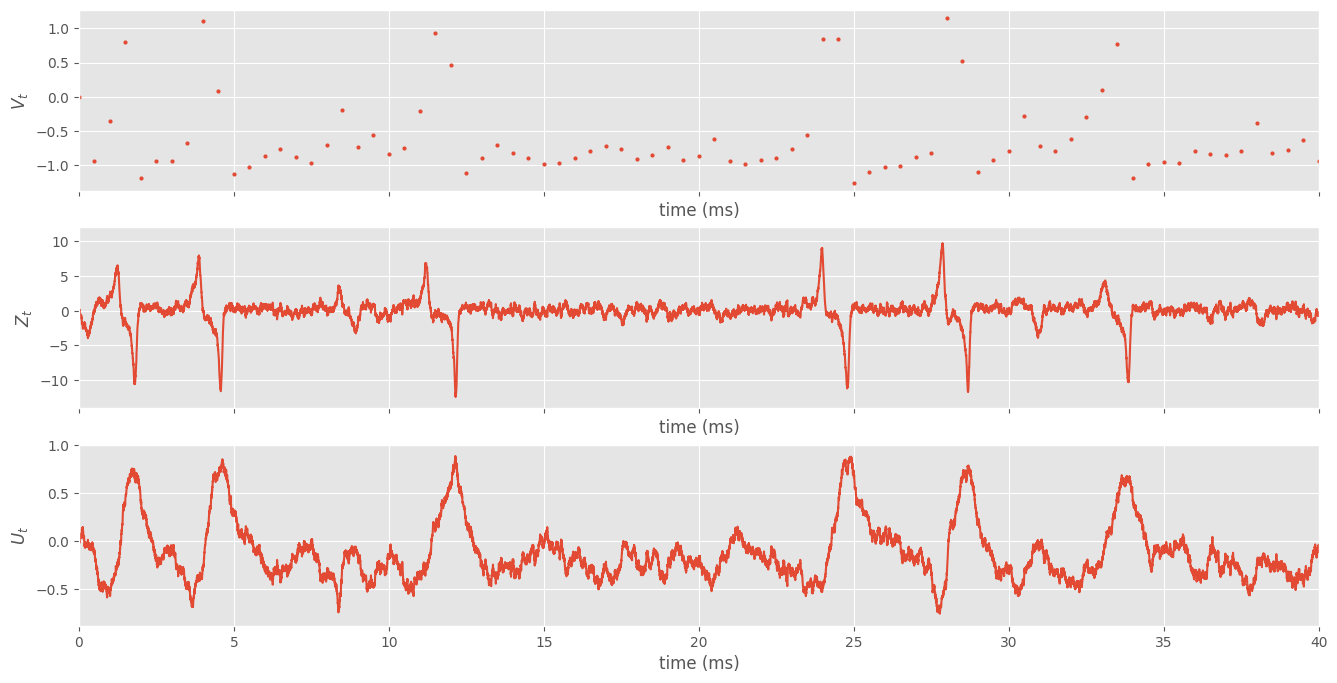

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True, squeeze=True)

subsample_delta_t = 0.5
sample_rate = int(subsample_delta_t / delta_t)

# axes[0].plot(times, iV_t, label=r'$V_t$')
axes[1].plot(times, iZ_t, label=r'$Z_t$')
axes[2].plot(times, iU_t, label=r'$U_t$')

axes[0].plot(times[::sample_rate], iV_t[::sample_rate], 'o', markersize=2.0)
# axes[1].plot(times[::sample_rate], samples_arr[:, 1][::sample_rate], 'o', markersize=5.0)


y_labels = [r'$V_t$', r'$Z_t$', r'$U_t$']
for ax, y_label in zip(axes, y_labels):
    ax.set_xlabel('time (ms)')
    ax.set_ylabel(y_label)
    ax.set_xlim((0.0, 40.0))

plt.show()

The simulations are the same, which means the maths is correct!

# Example simulation from a hypelliptic diffusion bridge proposal:

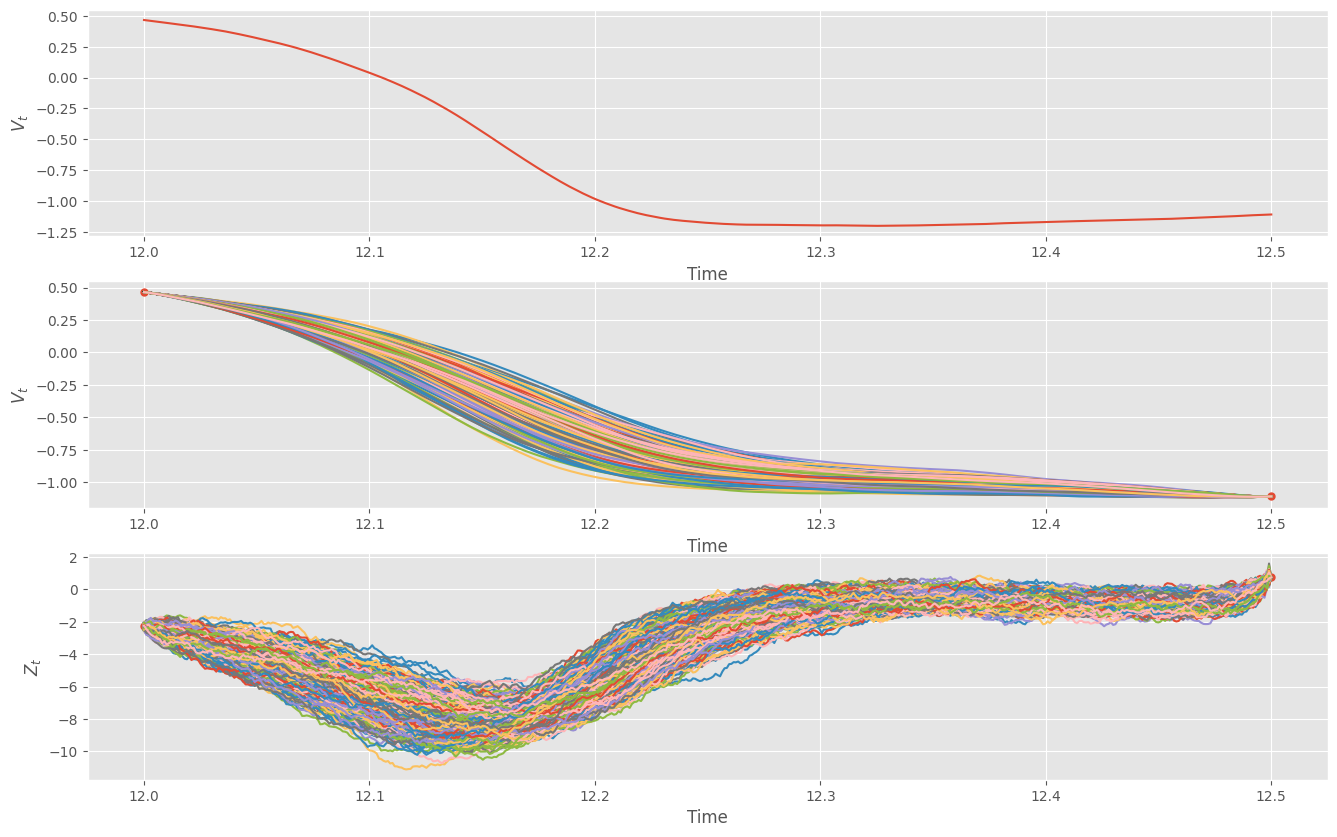

In [22]:
t_start = 12.0; t_end = 12.5
idx_start, idx_end = int(t_start / delta_t), int(t_end / delta_t)
time_span = t_end - t_start; bdelta_t = 0.001

v_0 = iV_t[idx_start]; z_0 = iZ_t[idx_start]
v_end = iV_t[idx_end]; z_end = iZ_t[idx_end]
bnum = int(time_span / bdelta_t)
N_samples = 1000
btimes = np.linspace(0.0, time_span, bnum)

x_0 = np.array([v_0, z_0]).reshape(1, 2)
x_end = np.array([v_end, z_end]).reshape(1, 2)

aux_bridge = axb.IntegratedNoDriftBrownianAuxBridge(isde, 0.0, time_span, x_end)

bridge_sims = aux_bridge.simulate(N_samples, x_0, num=bnum)
bridge_sims_arr = np.array([bridge_sims[name] for name in bridge_sims.dtype.names])

fig, axes = plt.subplots(3, 1, figsize=(16, 10))
y_labels = [r'$V_t$', r'$Z_t$']

start_idx = int(t_start / delta_t); end_idx = int(t_end / delta_t)
data_times = np.linspace(t_start, t_end, end_idx - start_idx)
axes[0].plot(data_times, iV_t[start_idx:end_idx], label=r'$V_t$')
axes[0].set_ylabel(y_labels[0])
axes[0].set_xlabel('Time')


for i, ax in enumerate(axes[1:]):
    ax.plot([t_start, t_end], [x_0[0, i], x_end[0, i]], 'o', markersize=5.0)
    ax.plot(t_start + btimes, bridge_sims_arr[:, :, i], label=y_labels[i])
    ax.set_ylabel(y_labels[i])
    ax.set_xlabel('Time')
    
plt.show()